# Large-Cap Tech Stocks — OHLCV Download & Signal Labelling (2015–2025)

**Part 1** downloads raw OHLCV data and saves it to Parquet. Run once.

**Part 2** loads the Parquet and applies labelling strategies. Re-run freely.

---

### Dependencies
```bash
pip install yfinance pandas numpy matplotlib pyarrow
```


---
# Part 1 — Download
_Run once. Saves raw OHLCV to Parquet._

## 1.1 Imports

In [ ]:
import os, time, warnings
import numpy as np
import pandas as pd
import yfinance as yf

warnings.filterwarnings('ignore')
print('✅ Imports OK')

✅ Imports OK


## 1.2 Configuration

In [ ]:
START_DATE    = '2015-01-01'
END_DATE      = '2025-01-01'
OUTPUT_DIR    = 'stock_data'
REQUEST_DELAY = 0.3

PARQUET_PATH = os.path.join(OUTPUT_DIR, 'large_cap_2015_2025_raw.parquet')

LARGE_CAP_TICKERS = [
    'AAPL', 'MSFT', 'NVDA', 'ORCL', 'CSCO',
    'IBM',  'AMD',  'CRM',  'INTC', 'QCOM',
]

print(f'Output → {PARQUET_PATH}')

Output → stock_data/large_cap_2015_2025_raw.parquet


## 1.3 Download Function

In [ ]:
def download_ticker(ticker: str) -> 'pd.DataFrame | None':
    print(f'  Downloading {ticker} ...', end=' ', flush=True)
    try:
        raw = yf.download(ticker, start=START_DATE, end=END_DATE,
                          auto_adjust=False, progress=False)
        if raw.empty:
            print('⚠  No data — skipping.')
            return None

        if isinstance(raw.columns, pd.MultiIndex):
            raw.columns = ['_'.join(c).strip('_') for c in raw.columns]

        col_map = {}
        for c in raw.columns:
            lc = c.lower()
            if   'adj' in lc and 'close' in lc: col_map[c] = 'Adj_Close'
            elif 'close'  in lc: col_map[c] = 'Close'
            elif 'open'   in lc: col_map[c] = 'Open'
            elif 'high'   in lc: col_map[c] = 'High'
            elif 'low'    in lc: col_map[c] = 'Low'
            elif 'volume' in lc: col_map[c] = 'Volume'
        raw.rename(columns=col_map, inplace=True)

        required = {'Open', 'High', 'Low', 'Close', 'Adj_Close', 'Volume'}
        missing  = required - set(raw.columns)
        if missing:
            print(f'⚠  Missing {missing} — skipping.')
            return None

        df = raw[list(required)].copy()
        df.index = pd.to_datetime(df.index)
        df.index.name = 'Date'
        df = df.sort_index()

        adj_factor     = df['Adj_Close'] / df['Close'].replace(0, np.nan)
        df['Adj_Open'] = df['Open']  * adj_factor
        df['Adj_High'] = df['High']  * adj_factor
        df['Adj_Low']  = df['Low']   * adj_factor
        df = df[['Open','High','Low','Close','Adj_Open','Adj_High','Adj_Low','Adj_Close','Volume']]
        df['Ticker'] = ticker

        print(f'✓  {len(df)} rows')
        return df
    except Exception as e:
        print(f'✗  {e}')
        return None

## 1.4 Download All Tickers

In [ ]:
os.makedirs(OUTPUT_DIR, exist_ok=True)
all_frames, failed = [], []

for ticker in LARGE_CAP_TICKERS:
    df = download_ticker(ticker)
    if df is None:
        failed.append(ticker)
        continue
    all_frames.append(df)
    time.sleep(REQUEST_DELAY)

raw_combined = pd.concat(all_frames).sort_values(['Ticker', 'Date'])
raw_combined.to_parquet(PARQUET_PATH, index=True)

print(f'\n✅ Done — {len(all_frames)}/10 tickers downloaded')
print(f'   Shape  : {raw_combined.shape}')
print(f'   Saved  : {PARQUET_PATH}')
if failed:
    print(f'   Failed : {", ".join(failed)}')


✅ Done — 10/10 tickers downloaded
   Shape  : (25160, 10)
   Saved  : stock_data/large_cap_2015_2025_raw.parquet


---
# Part 2 — Labelling Experiments
_Loads the Parquet. Re-run freely without re-downloading._

## 2.1 Imports

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from matplotlib.lines import Line2D
# pandas / numpy / os already imported in Part 1
# If running Part 2 standalone, uncomment:
# import os, warnings, numpy as np, pandas as pd
# warnings.filterwarnings('ignore')
print('✅ Imports OK')

✅ Imports OK


## 2.2 Configuration

In [ ]:
# ── Re-declare if running Part 2 standalone ──────────────────────────────────
OUTPUT_DIR   = 'stock_data'
PARQUET_PATH = os.path.join(OUTPUT_DIR, 'large_cap_2015_2025_raw.parquet')
LARGE_CAP_TICKERS = [
    'AAPL', 'MSFT', 'NVDA', 'ORCL', 'CSCO',
    'IBM',  'AMD',  'CRM',  'INTC', 'QCOM',
]

# ── Turning-point window ──────────────────────────────────────────────────────
# Half-width for local min/max detection. WINDOW=5 → 11-day centred window.
WINDOW = 5

# ── Active strategy ───────────────────────────────────────────────────────────
# 'turning_point'    → only the exact local min/max
# 'neighbour_spread' → turning point + ±NEIGHBOUR_SPREAD days around it
LABEL_STRATEGY   = 'neighbour_spread'
NEIGHBOUR_SPREAD = 1   # only used by neighbour_spread
FORWARD_DAYS     = 5   # only used by forward_5day

LABEL_COLORS = {'BUY': '#26a69a', 'SELL': '#ef5350', 'HOLD': '#bdbdbd'}

print(f'Strategy : {LABEL_STRATEGY}')
if LABEL_STRATEGY == 'neighbour_spread':
    print(f'  Spread : ±{NEIGHBOUR_SPREAD} day(s) around each turning point')
if LABEL_STRATEGY == 'forward_5day':
    print(f'  Horizon: {FORWARD_DAYS} trading days forward')
print(f'Window   : ±{WINDOW} days')

Strategy : neighbour_spread
  Spread : ±1 day(s) around each turning point
Window   : ±5 days


## 2.3 Load Raw Data

In [ ]:
raw = pd.read_parquet(PARQUET_PATH)
print(f'Loaded {len(raw):,} rows across {raw["Ticker"].nunique()} tickers')
print(f'Date range: {raw.index.min().date()} → {raw.index.max().date()}')
display(raw.head(3))

Loaded 25,160 rows across 10 tickers
Date range: 2015-01-02 → 2024-12-31


,Open,High,Low,Close,Adj_Open,Adj_High,Adj_Low,Adj_Close,Volume,Ticker
Date,,,,,,,,,,
2015-01-02,27.8475,27.860001,26.837500,27.332500,24.671151,24.682226,23.776353,24.214893,212818400,AAPL
2015-01-05,27.0725,27.162500,26.352501,26.562500,23.984547,24.064282,23.346673,23.532719,257142000,AAPL
2015-01-06,26.6350,26.857500,26.157499,26.565001,23.596950,23.794071,23.173914,23.534935,263188400,AAPL


## 2.4 Labelling Strategies

Each strategy follows the signature `(df, window, **kwargs) -> df`.
Add new ones and register in `STRATEGIES` — the dispatcher picks the right one
based on `LABEL_STRATEGY` set above.


In [ ]:
# ── Shared helpers ────────────────────────────────────────────────────────────

def _find_turning_points(prices: pd.Series, window: int):
    w = 2 * window + 1
    local_min = prices.rolling(window=w, center=True, min_periods=1).min()
    local_max = prices.rolling(window=w, center=True, min_periods=1).max()
    return (prices == local_min), (prices == local_max)

def _encode(df):
    df['Label'] = df['Signal'].map({'HOLD': 0, 'BUY': 1, 'SELL': 2})
    return df


# ── Strategy: turning_point ───────────────────────────────────────────────────

def strategy_turning_point(df, window=WINDOW, **kwargs):
    """Labels only the exact local min/max within the ±window rolling window."""
    df = df.copy()
    is_buy, is_sell = _find_turning_points(df['Adj_Close'], window)
    df['Signal'] = 'HOLD'
    df.loc[is_buy,  'Signal'] = 'BUY'
    df.loc[is_sell, 'Signal'] = 'SELL'
    return _encode(df)


# ── Strategy: neighbour_spread ────────────────────────────────────────────────

def strategy_neighbour_spread(df, window=WINDOW, neighbour_spread=NEIGHBOUR_SPREAD, **kwargs):
    """
    Labels the turning point AND ±neighbour_spread days around it.
    SELL takes precedence over BUY on any overlap.
    """
    df = df.copy()
    is_buy, is_sell = _find_turning_points(df['Adj_Close'], window)
    spread_w = 2 * neighbour_spread + 1
    buy_dilated  = is_buy.astype(int).rolling(spread_w, center=True, min_periods=1).max().astype(bool)
    sell_dilated = is_sell.astype(int).rolling(spread_w, center=True, min_periods=1).max().astype(bool)
    df['Signal'] = 'HOLD'
    df.loc[buy_dilated,  'Signal'] = 'BUY'
    df.loc[sell_dilated, 'Signal'] = 'SELL'
    return _encode(df)



# ── Strategy: forward_5day ─────────────────────────────────────────────────────


def strategy_forward_5day(df, window=WINDOW, forward_days=FORWARD_DAYS, **kwargs):
    """
    BUY  — Adj_Close is higher than today on ALL of the next 5 days
    SELL — Adj_Close is lower than today on ALL of the next 5 days
    HOLD — otherwise
    """
    df = df.copy()
    today = df['Adj_Close']

    all_up   = pd.concat([today.shift(-i) > today for i in range(1, forward_days + 1)], axis=1).all(axis=1)
    all_down = pd.concat([today.shift(-i) < today for i in range(1, forward_days + 1)], axis=1).all(axis=1)

    df['Signal'] = 'HOLD'
    df.loc[all_up,   'Signal'] = 'BUY'
    df.loc[all_down, 'Signal'] = 'SELL'
    return _encode(df)


# ── Strategy: strategy_continuous_5day ─────────────────────────────────────────────────────


def strategy_continuous_5day(df, window=WINDOW, forward_days=FORWARD_DAYS, **kwargs):
    """
    BUY  — each of the next 5 days is strictly higher than the day before (continuous rise)
    SELL — each of the next 5 days is strictly lower than the day before (continuous fall)
    HOLD — otherwise
    """
    df = df.copy()
    today = df['Adj_Close']

    # day-over-day increases: day2>day1, day3>day2, day4>day3, day5>day4
    all_up   = pd.concat([today.shift(-i) > today.shift(-(i-1)) for i in range(1, forward_days + 1)], axis=1).all(axis=1)
    all_down = pd.concat([today.shift(-i) < today.shift(-(i-1)) for i in range(1, forward_days + 1)], axis=1).all(axis=1)

    df['Signal'] = 'HOLD'
    df.loc[all_up,   'Signal'] = 'BUY'
    df.loc[all_down, 'Signal'] = 'SELL'
    return _encode(df)

# ── Registry & dispatcher ─────────────────────────────────────────────────────

STRATEGIES = {
    'turning_point'    : strategy_turning_point,
    'neighbour_spread' : strategy_neighbour_spread,
    'forward_5day'     : strategy_forward_5day,
    'continuous_5day'    : strategy_continuous_5day
}

def label_signals(df, window=WINDOW, strategy=LABEL_STRATEGY, **kwargs):
    if strategy not in STRATEGIES:
        raise ValueError(f"Unknown strategy '{strategy}'. Available: {list(STRATEGIES.keys())}")
    return STRATEGIES[strategy](df, window=window, **kwargs)

print(f'Registered: {list(STRATEGIES.keys())}')

Registered: ['turning_point', 'neighbour_spread', 'forward_5day', 'continuous_5day']


## 2.5 Apply Labels

In [ ]:
labelled_frames = []
for ticker in LARGE_CAP_TICKERS:
    df = label_signals(
        raw[raw['Ticker'] == ticker],
        window=WINDOW,
        strategy=LABEL_STRATEGY,
        neighbour_spread=NEIGHBOUR_SPREAD,
        forward_days=FORWARD_DAYS,
    )
    labelled_frames.append(df)

combined = pd.concat(labelled_frames).sort_values(['Ticker', 'Date'])

spread_suffix = f'_s{NEIGHBOUR_SPREAD}' if LABEL_STRATEGY == 'neighbour_spread' else ''
out_path = os.path.join(OUTPUT_DIR, f'labelled_{LABEL_STRATEGY}{spread_suffix}.parquet')
combined.to_parquet(out_path, index=True)

print(f'✅ Labelled {combined.shape[0]:,} rows  |  strategy={LABEL_STRATEGY}  |  saved → {out_path}')

✅ Labelled 25,160 rows  |  strategy=neighbour_spread  |  saved → stock_data/labelled_neighbour_spread_s1.parquet


## 2.6 Label Distribution

In [ ]:
dist = (
    combined.groupby(['Ticker', 'Signal']).size()
    .unstack(fill_value=0)[['BUY', 'HOLD', 'SELL']]
)
dist['Total'] = dist.sum(axis=1)
dist['BUY%']  = (dist['BUY']  / dist['Total'] * 100).round(1)
dist['SELL%'] = (dist['SELL'] / dist['Total'] * 100).round(1)
print(f'Strategy: {LABEL_STRATEGY}')
display(dist)

Strategy: neighbour_spread


Signal,BUY,HOLD,SELL,Total,BUY%,SELL%
Ticker,,,,,,
AAPL,415,1695,406,2516,16.5,16.1
AMD,446,1582,488,2516,17.7,19.4
CRM,431,1627,458,2516,17.1,18.2
CSCO,451,1597,468,2516,17.9,18.6
IBM,445,1637,434,2516,17.7,17.2
INTC,438,1592,486,2516,17.4,19.3
MSFT,426,1621,469,2516,16.9,18.6
NVDA,433,1643,440,2516,17.2,17.5
ORCL,445,1643,428,2516,17.7,17.0


## 2.7 Price Charts

Chart saved → stock_data/signals_AAPL_all_strategies.png


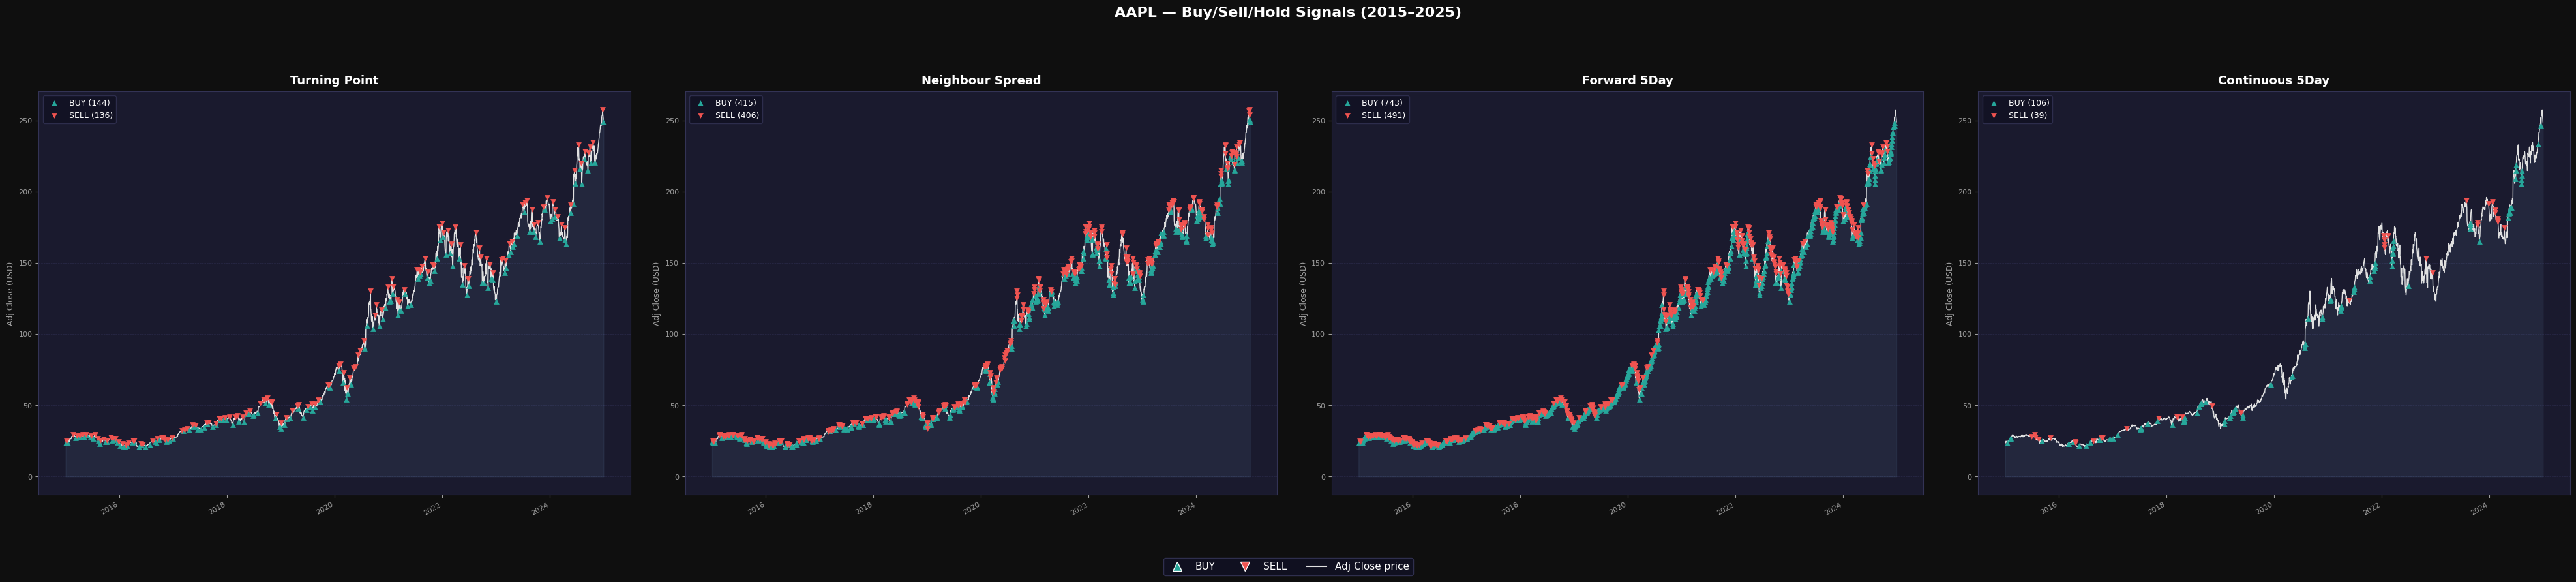

Chart saved → stock_data/signals_MSFT_all_strategies.png


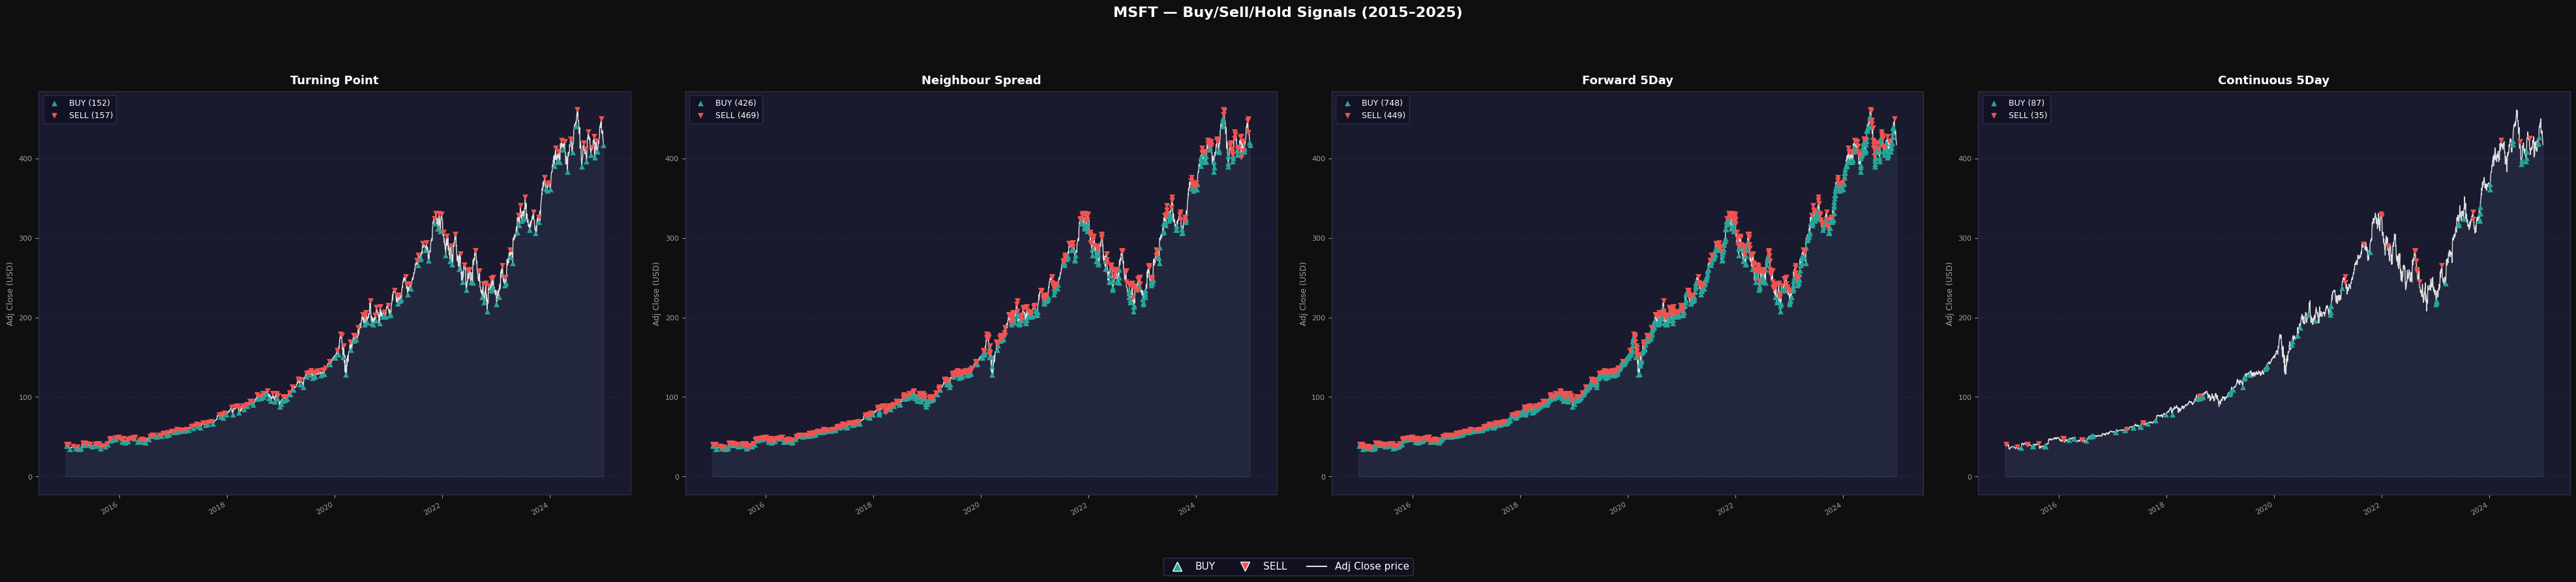

Chart saved → stock_data/signals_NVDA_all_strategies.png


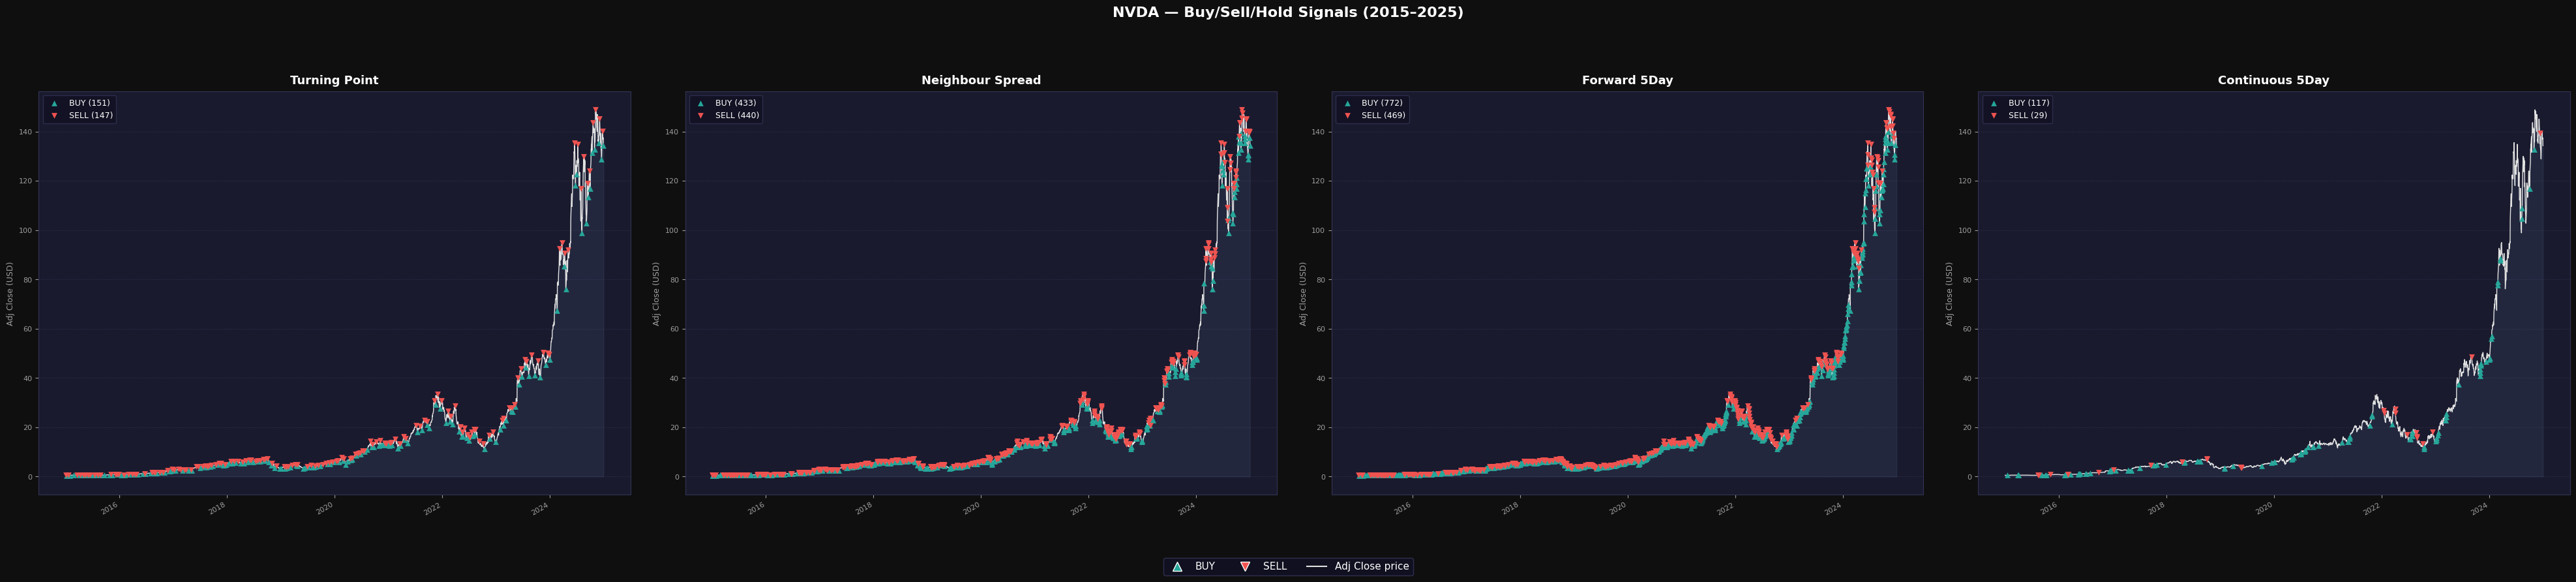

Chart saved → stock_data/signals_ORCL_all_strategies.png


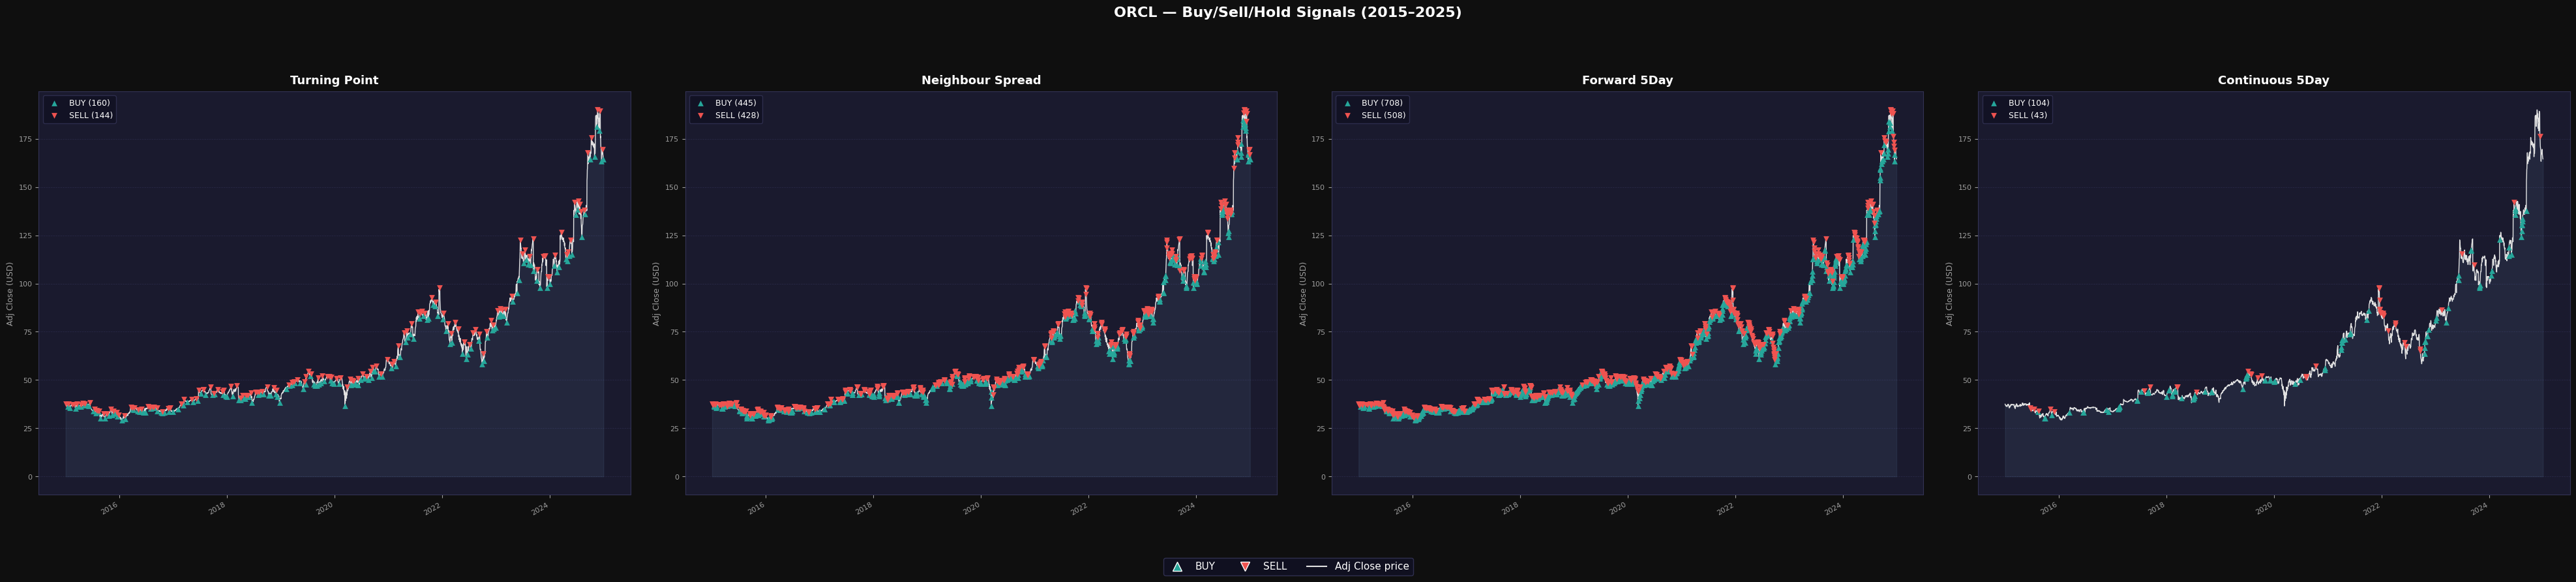

Chart saved → stock_data/signals_CSCO_all_strategies.png


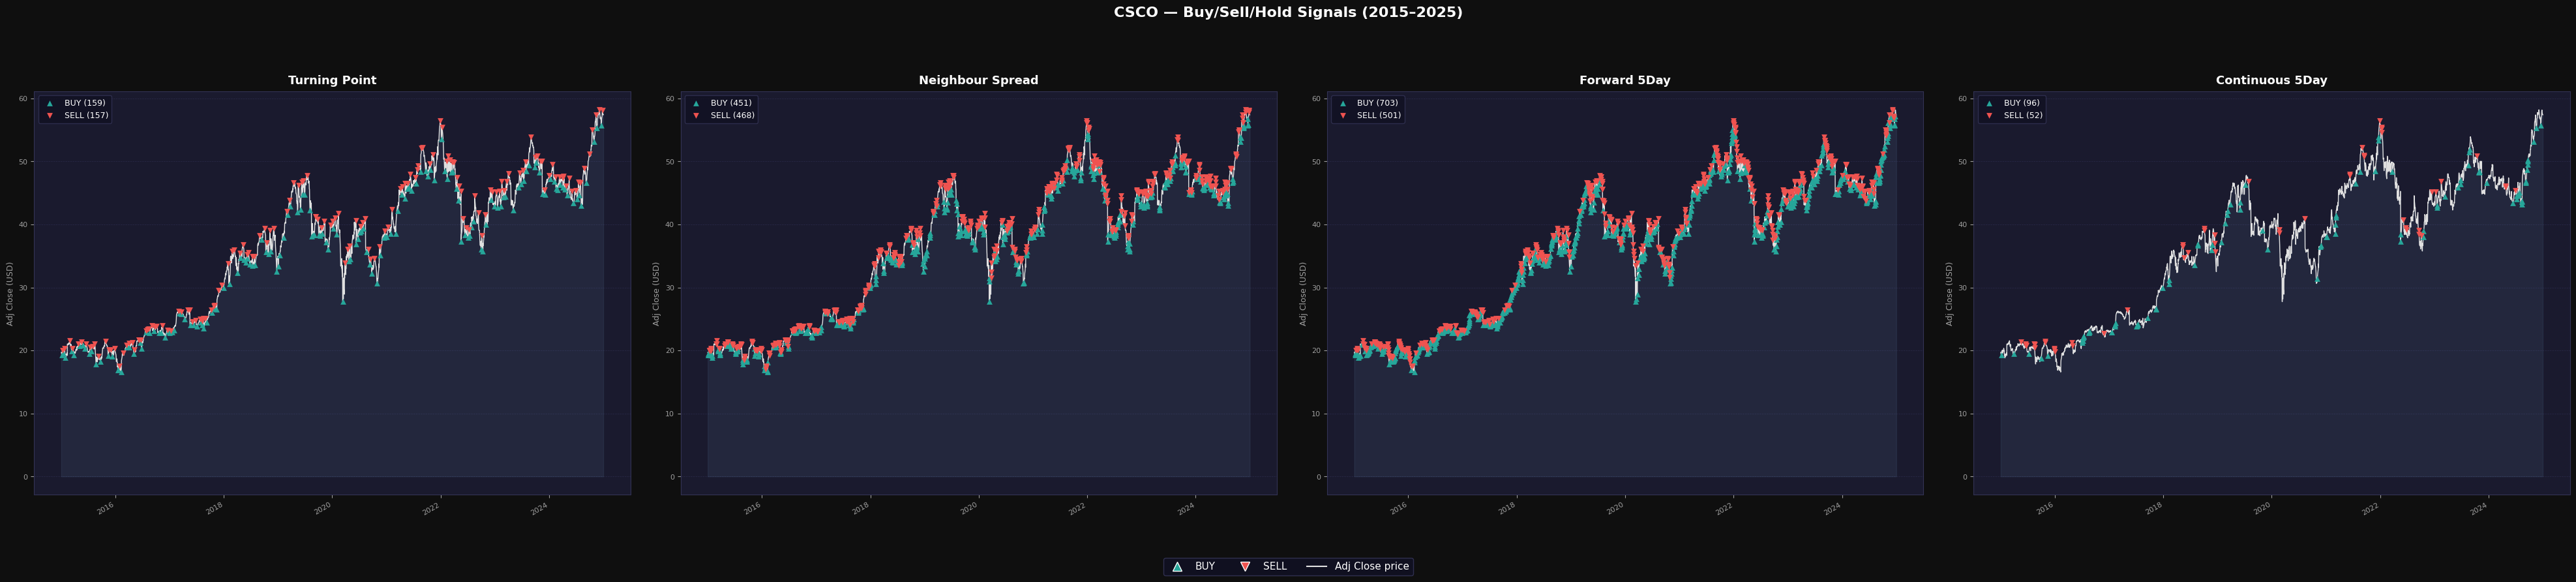

Chart saved → stock_data/signals_IBM_all_strategies.png


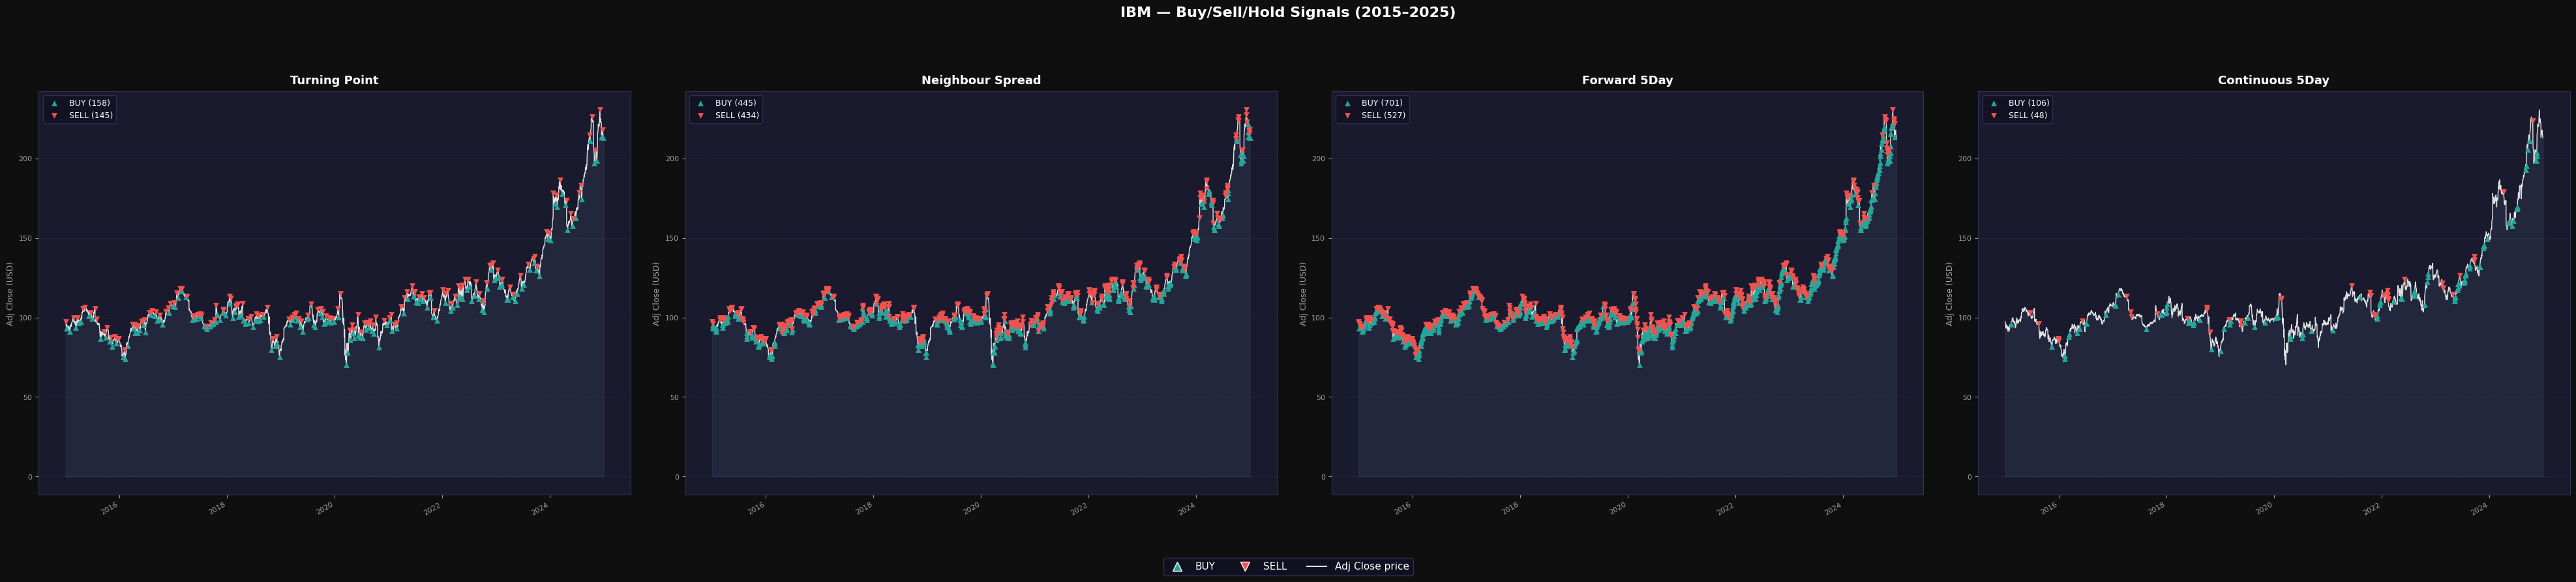

Chart saved → stock_data/signals_AMD_all_strategies.png


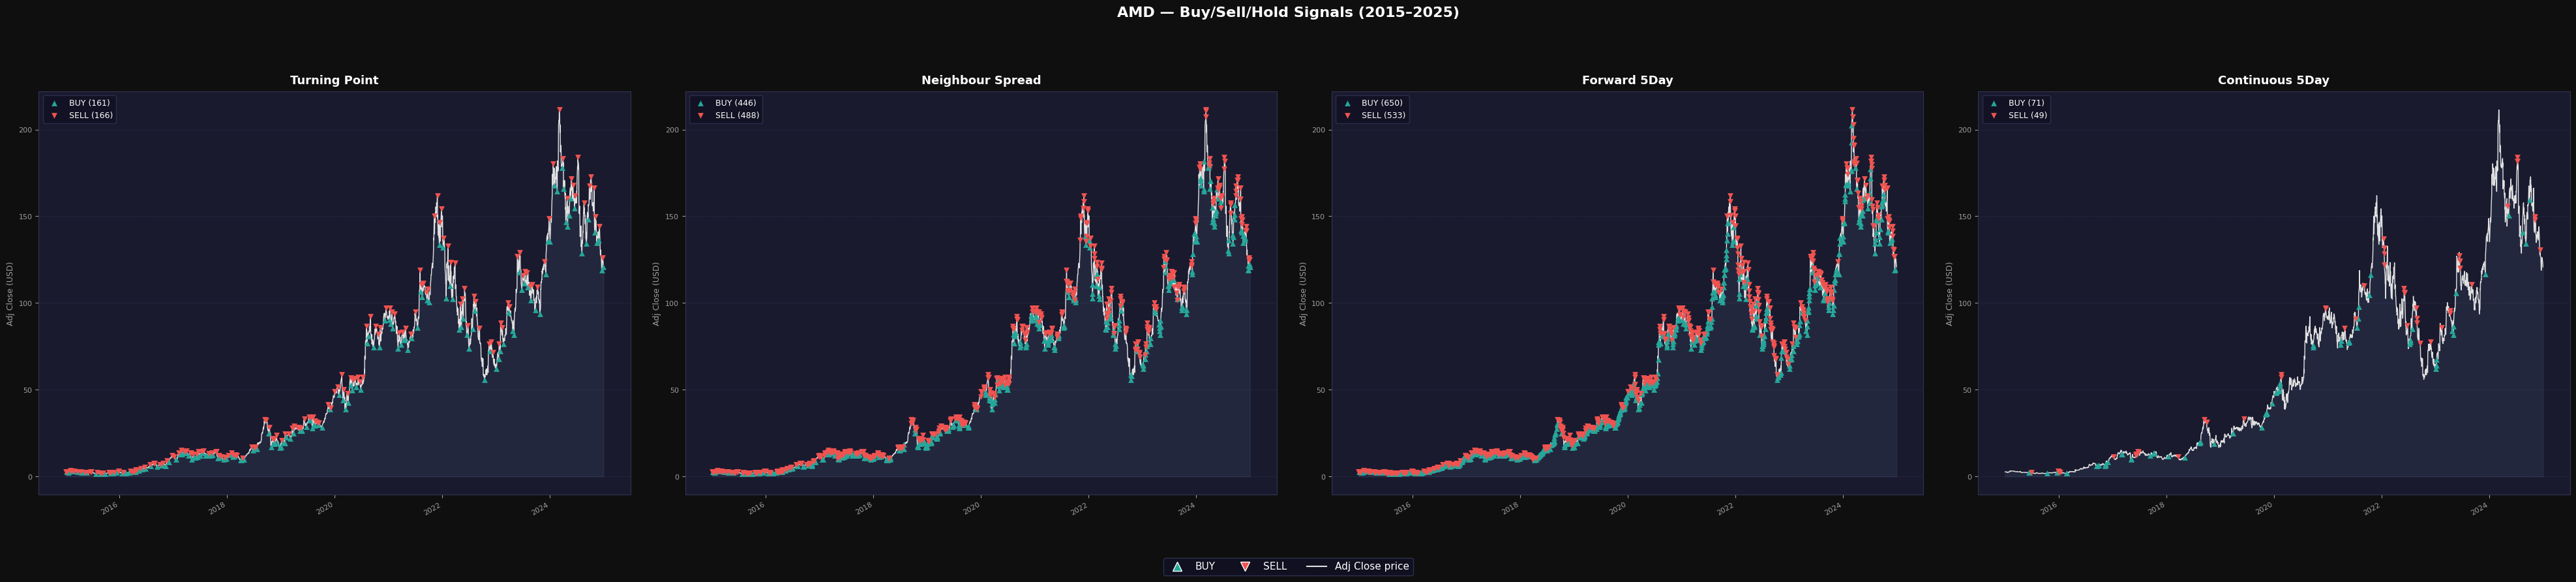

Chart saved → stock_data/signals_CRM_all_strategies.png


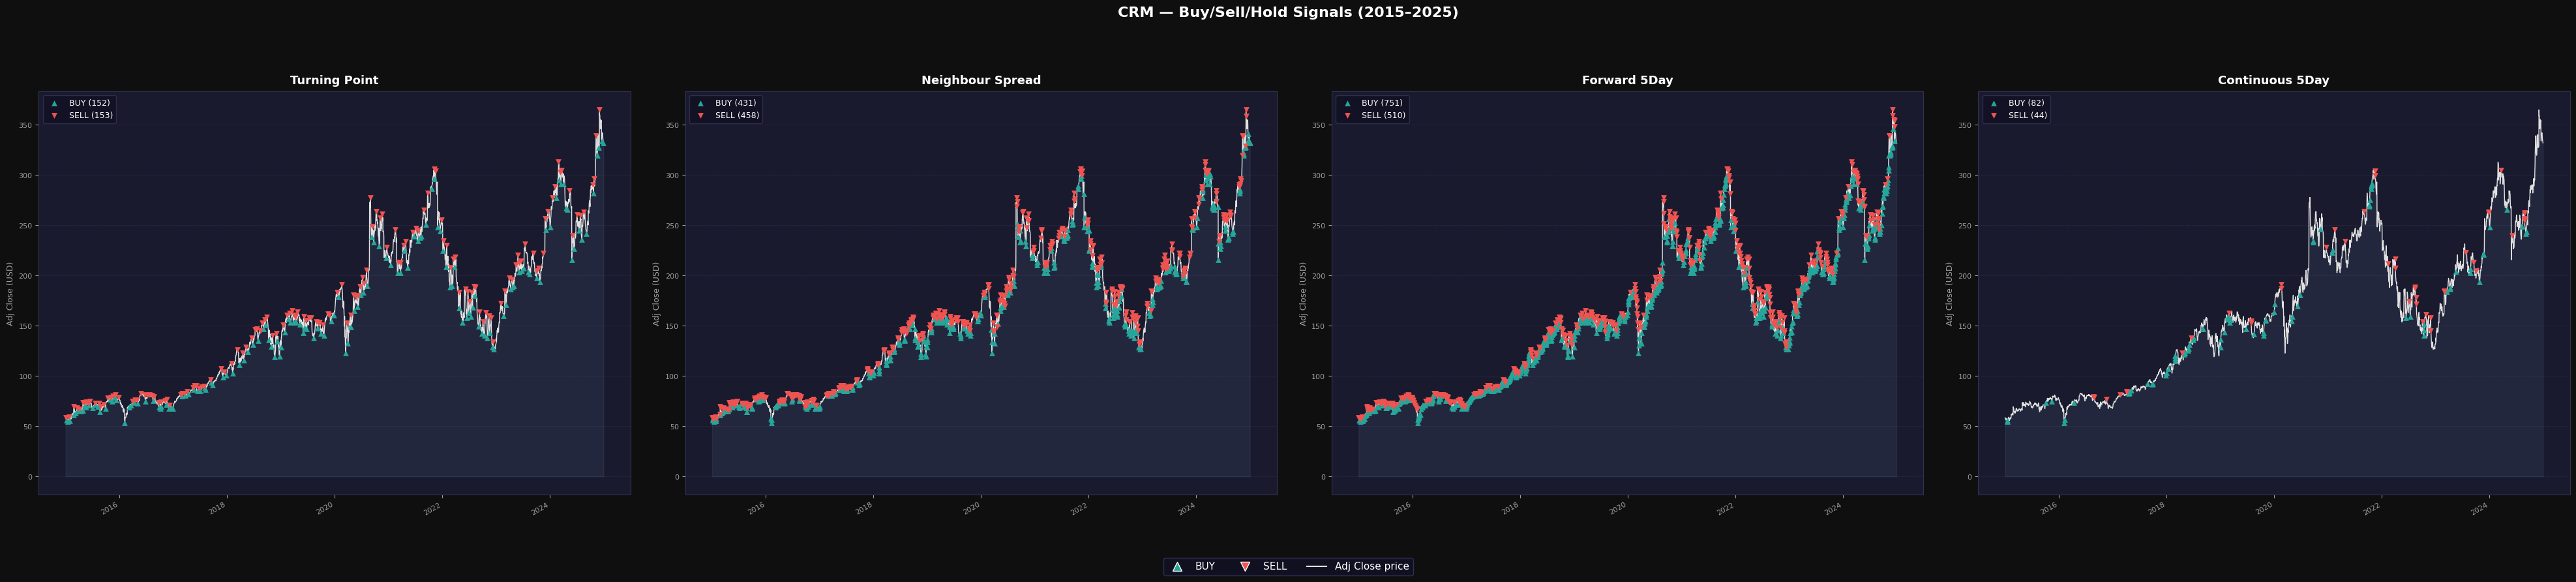

Chart saved → stock_data/signals_INTC_all_strategies.png


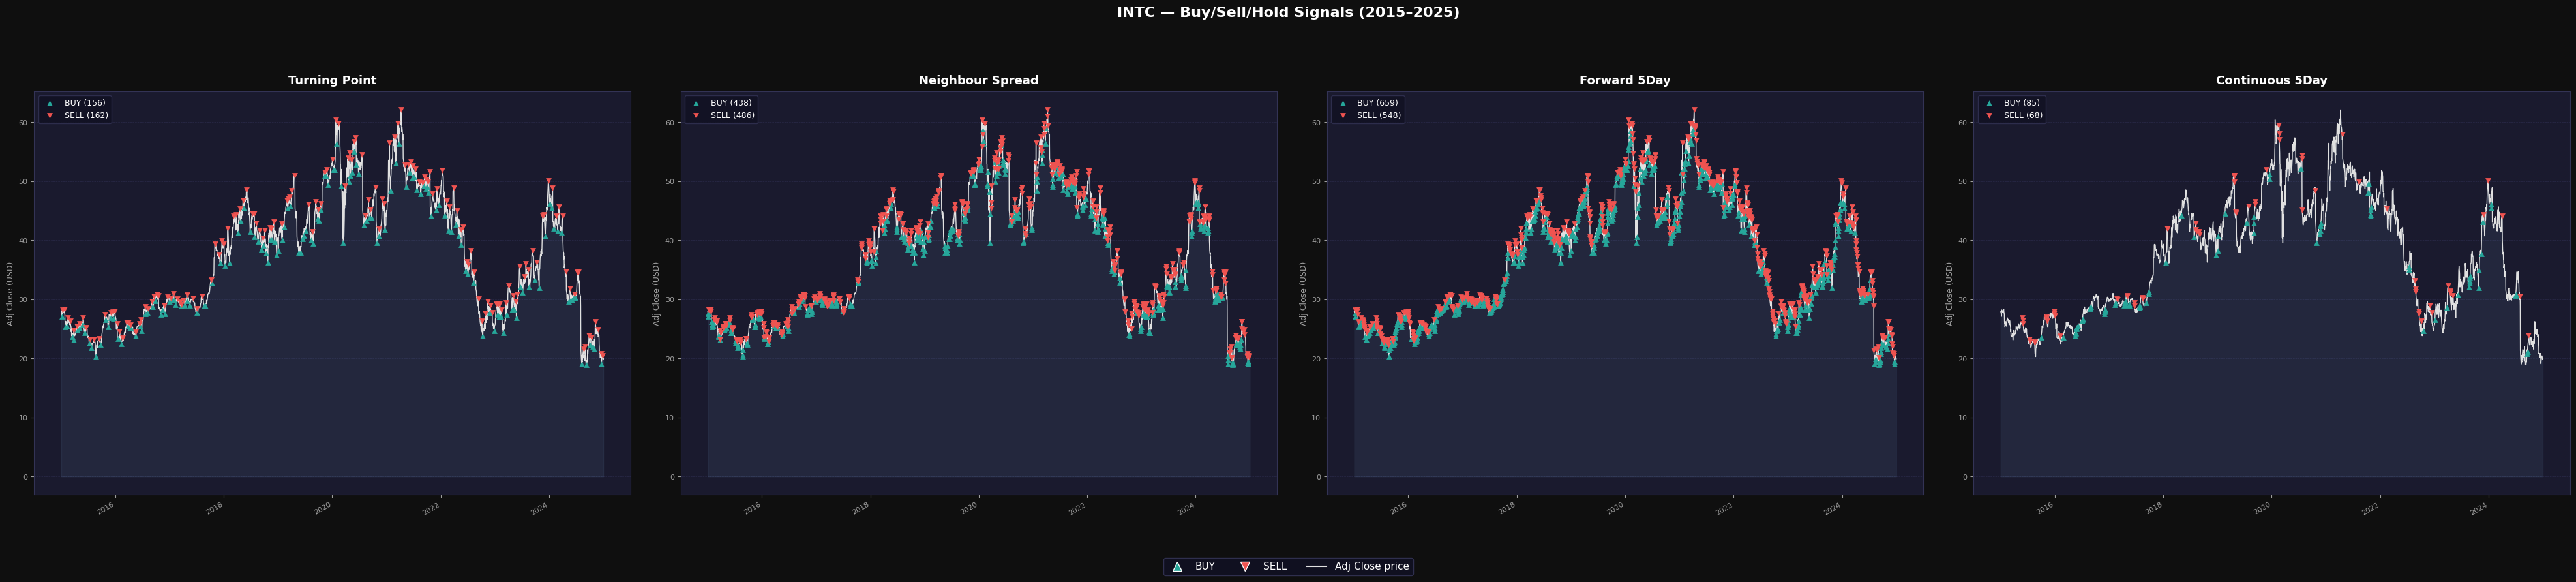

Chart saved → stock_data/signals_QCOM_all_strategies.png


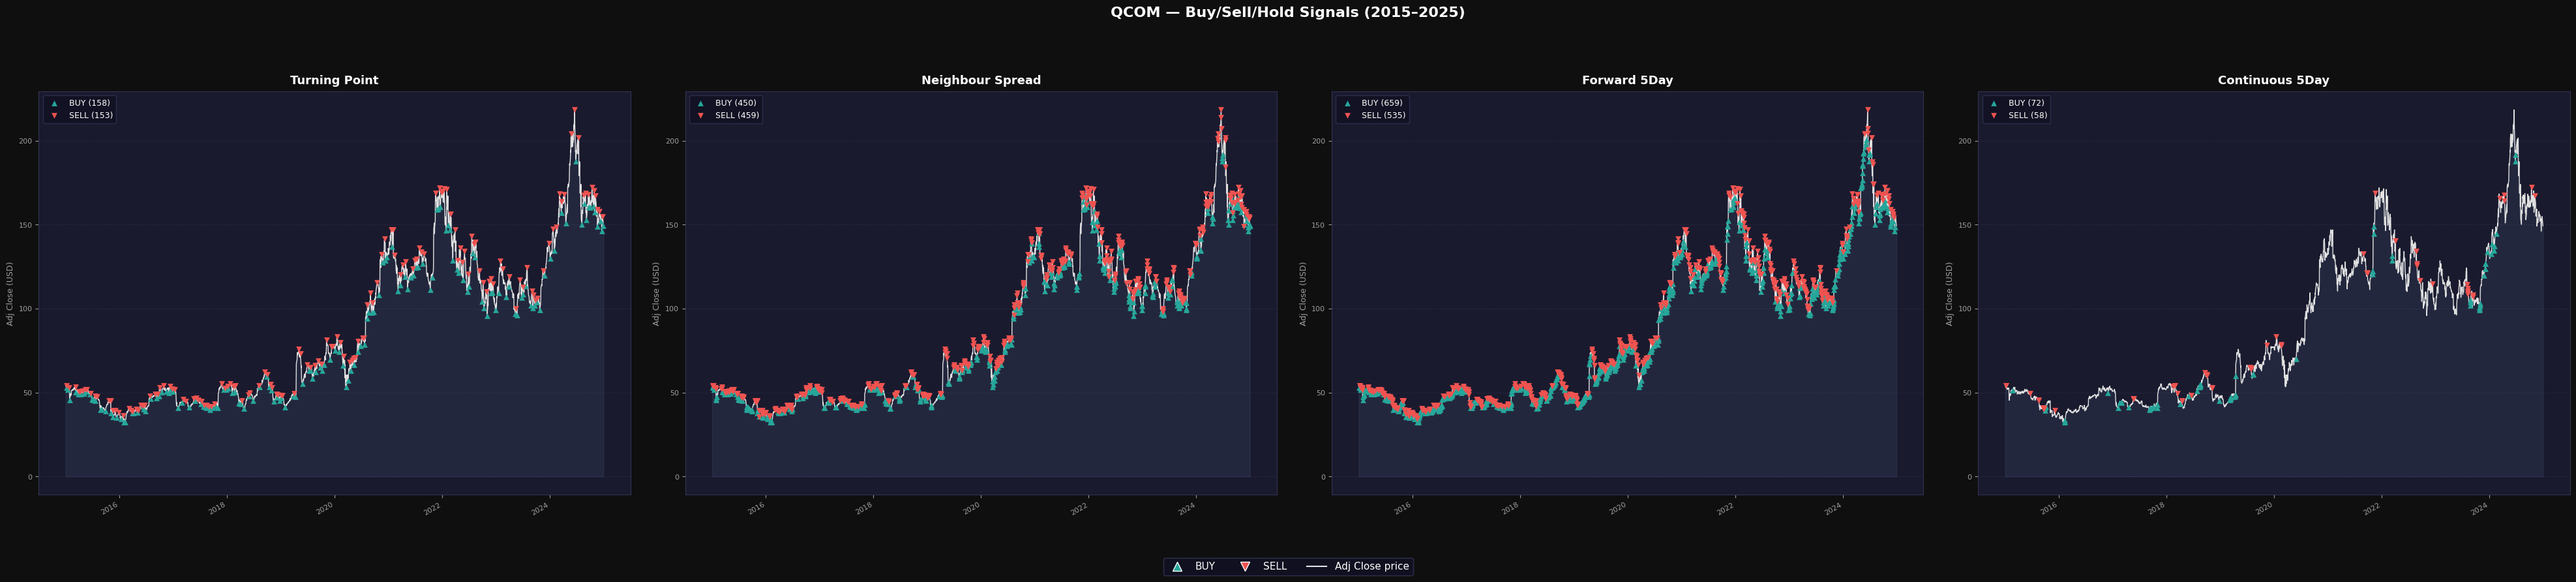

In [ ]:
strategy_names = list(STRATEGIES.keys())

for ticker in LARGE_CAP_TICKERS:
    ticker_raw = raw[raw['Ticker'] == ticker]

    fig, axes = plt.subplots(nrows=1, ncols=4, figsize=(40, 8), facecolor='#0f0f0f')
    fig.suptitle(
        f'{ticker} — Buy/Sell/Hold Signals (2015–2025)',
        color='white', fontsize=16, fontweight='bold', y=1.02,
    )

    for col_idx, strategy_name in enumerate(strategy_names):
        ax = axes[col_idx]
        fn = STRATEGIES[strategy_name]
        df = fn(ticker_raw, window=WINDOW, neighbour_spread=NEIGHBOUR_SPREAD, forward_days=FORWARD_DAYS)

        ax.plot(df.index, df['Adj_Close'], color='#e0e0e0', linewidth=1.0, zorder=2)
        ax.fill_between(df.index, df['Adj_Close'], alpha=0.08, color='#90caf9')
        for sig, marker in [('BUY', '^'), ('SELL', 'v')]:
            sub = df[df['Signal'] == sig]
            ax.scatter(sub.index, sub['Adj_Close'], marker=marker,
                       color=LABEL_COLORS[sig], s=40, zorder=5, linewidths=0,
                       label=f'{sig} ({len(sub)})')
        ax.set_facecolor('#1a1a2e')
        ax.set_title(strategy_name.replace('_', ' ').title(),
                     color='white', fontsize=13, fontweight='bold', pad=8)
        ax.set_ylabel('Adj Close (USD)', color='#9e9e9e', fontsize=9)
        ax.tick_params(colors='#9e9e9e', labelsize=8)
        for spine in ax.spines.values(): spine.set_edgecolor('#333355')
        ax.xaxis.set_major_locator(mdates.YearLocator(2))
        ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
        plt.setp(ax.xaxis.get_majorticklabels(), rotation=30, ha='right')
        ax.yaxis.grid(True, color='#2a2a4a', linewidth=0.5, linestyle='--')
        ax.set_axisbelow(True)
        ax.legend(fontsize=9, loc='upper left', facecolor='#111122',
                  edgecolor='#333355', labelcolor='white', framealpha=0.8)

    fig.legend(
        handles=[
            Line2D([0],[0], marker='^', color='w', markerfacecolor=LABEL_COLORS['BUY'],
                   markersize=10, linestyle='None', label='BUY'),
            Line2D([0],[0], marker='v', color='w', markerfacecolor=LABEL_COLORS['SELL'],
                   markersize=10, linestyle='None', label='SELL'),
            Line2D([0],[0], color='#e0e0e0', linewidth=1.5, label='Adj Close price'),
        ],
        loc='lower center', ncol=3, bbox_to_anchor=(0.5, -0.08),
        facecolor='#111122', edgecolor='#333355', labelcolor='white', fontsize=11, framealpha=0.9,
    )
    plt.tight_layout(pad=2.5)
    chart_path = os.path.join(OUTPUT_DIR, f'signals_{ticker}_all_strategies.png')
    plt.savefig(chart_path, dpi=150, bbox_inches='tight', facecolor='#0f0f0f')
    print(f'Chart saved → {chart_path}')
    plt.show()

## 2.8 Strategy Comparison

In [ ]:
for ticker in LARGE_CAP_TICKERS:
    ticker_raw = raw[raw['Ticker'] == ticker]

    rows = []
    for name, fn in STRATEGIES.items():
        counts = fn(ticker_raw, window=WINDOW, neighbour_spread=NEIGHBOUR_SPREAD, forward_days=FORWARD_DAYS)['Signal'].value_counts().rename(name)
        rows.append(counts)

    comp = pd.DataFrame(rows).fillna(0).astype(int)[['BUY', 'HOLD', 'SELL']]
    comp['Total'] = comp.sum(axis=1)
    comp['BUY%']  = (comp['BUY']  / comp['Total'] * 100).round(1)
    comp['SELL%'] = (comp['SELL'] / comp['Total'] * 100).round(1)
    print(f'Strategy comparison — {ticker}  (WINDOW={WINDOW}, NEIGHBOUR_SPREAD={NEIGHBOUR_SPREAD})')
    display(comp)
    print()

Strategy comparison — AAPL  (WINDOW=5, NEIGHBOUR_SPREAD=1)


Signal,BUY,HOLD,SELL,Total,BUY%,SELL%
turning_point,144,2236,136,2516,5.7,5.4
neighbour_spread,415,1695,406,2516,16.5,16.1
forward_5day,743,1282,491,2516,29.5,19.5
continuous_5day,106,2371,39,2516,4.2,1.6



Strategy comparison — MSFT  (WINDOW=5, NEIGHBOUR_SPREAD=1)


Signal,BUY,HOLD,SELL,Total,BUY%,SELL%
turning_point,152,2207,157,2516,6.0,6.2
neighbour_spread,426,1621,469,2516,16.9,18.6
forward_5day,748,1319,449,2516,29.7,17.8
continuous_5day,87,2394,35,2516,3.5,1.4



Strategy comparison — NVDA  (WINDOW=5, NEIGHBOUR_SPREAD=1)


...

Signal,BUY,HOLD,SELL,Total,BUY%,SELL%
turning_point,152,2211,153,2516,6.0,6.1
neighbour_spread,431,1627,458,2516,17.1,18.2
forward_5day,751,1255,510,2516,29.8,20.3
continuous_5day,82,2390,44,2516,3.3,1.7



Strategy comparison — INTC  (WINDOW=5, NEIGHBOUR_SPREAD=1)


Signal,BUY,HOLD,SELL,Total,BUY%,SELL%
turning_point,156,2198,162,2516,6.2,6.4
neighbour_spread,438,1592,486,2516,17.4,19.3
forward_5day,659,1309,548,2516,26.2,21.8
continuous_5day,85,2363,68,2516,3.4,2.7



Strategy comparison — QCOM  (WINDOW=5, NEIGHBOUR_SPREAD=1)


Signal,BUY,HOLD,SELL,Total,BUY%,SELL%
turning_point,158,2205,153,2516,6.3,6.1
neighbour_spread,450,1607,459,2516,17.9,18.2
forward_5day,659,1322,535,2516,26.2,21.3
continuous_5day,72,2386,58,2516,2.9,2.3


---
# Part 3 — Technical Indicator Engineering
_Loads raw OHLCV, computes 10 ML-optimised TA indicators, applies `forward_5day` labelling, and saves to `../data/technical_dataset.csv`._

### Indicators
| # | Name | Params | Category |
|---|------|--------|----------|
| 1 | RSI | 14 | Momentum |
| 2 | MACD Histogram | 12,26,9 | Momentum |
| 3 | Rate of Change | 5d | Momentum |
| 4 | Stochastic %K | 14,3 | Momentum |
| 5 | ADX | 14 | Trend Strength |
| 6 | ATR (normalised) | 14 | Volatility |
| 7 | Bollinger %B | 20, 2σ | Volatility |
| 8 | EMA Ratio | Close/EMA20 | Trend |
| 9 | OBV Rate of Change | 5d | Volume |
| 10 | Volume Ratio | Vol/Vol_MA20 | Volume |

## 3.1 Imports & Config

In [ ]:
import os
import numpy as np
import pandas as pd
import warnings
warnings.filterwarnings('ignore')

# ── Paths ─────────────────────────────────────────────────────────────────────
PARQUET_PATH = os.path.join('stock_data', 'large_cap_2015_2025_raw.parquet')
OUTPUT_CSV   = os.path.join('..', 'data', 'technical_dataset.csv')

LARGE_CAP_TICKERS = [
    'AAPL', 'MSFT', 'NVDA', 'ORCL', 'CSCO',
    'IBM',  'AMD',  'CRM',  'INTC', 'QCOM',
]

# ── Labelling params ──────────────────────────────────────────────────────────
FORWARD_DAYS = 5   # prediction horizon

print(f'PARQUET  → {PARQUET_PATH}')
print(f'OUTPUT   → {OUTPUT_CSV}')
print(f'Horizon  : {FORWARD_DAYS} trading days')

## 3.2 Technical Indicator Functions

In [ ]:
def compute_rsi(close: pd.Series, period: int = 14) -> pd.Series:
    """RSI — bounded 0–100. Uses Wilder's smoothing (EMA with alpha=1/period)."""
    delta = close.diff()
    gain  = delta.clip(lower=0)
    loss  = (-delta).clip(lower=0)
    avg_gain = gain.ewm(alpha=1/period, min_periods=period, adjust=False).mean()
    avg_loss = loss.ewm(alpha=1/period, min_periods=period, adjust=False).mean()
    rs  = avg_gain / avg_loss.replace(0, np.nan)
    rsi = 100 - (100 / (1 + rs))
    return rsi.rename('rsi_14')


def compute_macd_hist(close: pd.Series,
                      fast: int = 12, slow: int = 26, signal: int = 9) -> pd.Series:
    """MACD Histogram = MACD line − Signal line. Rate-of-change of momentum."""
    ema_fast   = close.ewm(span=fast,   adjust=False).mean()
    ema_slow   = close.ewm(span=slow,   adjust=False).mean()
    macd_line  = ema_fast - ema_slow
    signal_line = macd_line.ewm(span=signal, adjust=False).mean()
    return (macd_line - signal_line).rename('macd_hist')


def compute_roc(close: pd.Series, period: int = 5) -> pd.Series:
    """Rate of Change — % change over `period` days. Aligned to forward horizon."""
    return ((close / close.shift(period)) - 1).rename(f'roc_{period}')


def compute_stoch_k(high: pd.Series, low: pd.Series, close: pd.Series,
                    k_period: int = 14, d_period: int = 3) -> pd.Series:
    """Stochastic %K — bounded 0–100. Uses rolling high/low over k_period."""
    lowest_low   = low.rolling(k_period).min()
    highest_high = high.rolling(k_period).max()
    denom = (highest_high - lowest_low).replace(0, np.nan)
    raw_k = 100 * (close - lowest_low) / denom
    # Smooth with d_period SMA to reduce noise
    stoch_k = raw_k.rolling(d_period).mean()
    return stoch_k.rename('stoch_k')


def compute_adx(high: pd.Series, low: pd.Series, close: pd.Series,
                period: int = 14) -> pd.Series:
    """ADX — trend strength (0–100). Higher = stronger trend regardless of direction."""
    high_diff = high.diff()
    low_diff  = (-low.diff())

    plus_dm  = np.where((high_diff > low_diff) & (high_diff > 0), high_diff, 0.0)
    minus_dm = np.where((low_diff > high_diff) & (low_diff > 0),  low_diff,  0.0)

    tr = pd.concat([
        high - low,
        (high - close.shift()).abs(),
        (low  - close.shift()).abs(),
    ], axis=1).max(axis=1)

    atr      = tr.ewm(alpha=1/period, min_periods=period, adjust=False).mean()
    plus_di  = 100 * pd.Series(plus_dm,  index=close.index).ewm(alpha=1/period, min_periods=period, adjust=False).mean() / atr.replace(0, np.nan)
    minus_di = 100 * pd.Series(minus_dm, index=close.index).ewm(alpha=1/period, min_periods=period, adjust=False).mean() / atr.replace(0, np.nan)

    dx  = 100 * (plus_di - minus_di).abs() / (plus_di + minus_di).replace(0, np.nan)
    adx = dx.ewm(alpha=1/period, min_periods=period, adjust=False).mean()
    return adx.rename('adx_14')


def compute_atr_norm(high: pd.Series, low: pd.Series, close: pd.Series,
                     period: int = 14) -> pd.Series:
    """ATR normalised by close price (%). Scale-free volatility measure."""
    tr = pd.concat([
        high - low,
        (high - close.shift()).abs(),
        (low  - close.shift()).abs(),
    ], axis=1).max(axis=1)
    atr = tr.ewm(alpha=1/period, min_periods=period, adjust=False).mean()
    return (atr / close).rename('atr_norm_14')


def compute_bb_pct(close: pd.Series, period: int = 20, n_std: float = 2.0) -> pd.Series:
    """Bollinger %B — position of close within the band (0 = lower, 1 = upper)."""
    ma    = close.rolling(period).mean()
    std   = close.rolling(period).std(ddof=0)
    upper = ma + n_std * std
    lower = ma - n_std * std
    denom = (upper - lower).replace(0, np.nan)
    return ((close - lower) / denom).rename('bb_pct_20')


def compute_ema_ratio(close: pd.Series, period: int = 20) -> pd.Series:
    """EMA Ratio = Close / EMA(period). > 1 → above trend; < 1 → below trend."""
    ema = close.ewm(span=period, adjust=False).mean()
    return (close / ema).rename(f'ema_ratio_{period}')


def compute_obv_roc(close: pd.Series, volume: pd.Series, period: int = 5) -> pd.Series:
    """OBV Rate of Change over `period` days. Volume momentum aligned to horizon."""
    direction = np.sign(close.diff()).fillna(0)
    obv = (direction * volume).cumsum()
    obv_roc = ((obv / obv.shift(period).replace(0, np.nan)) - 1)
    return obv_roc.rename(f'obv_roc_{period}')


def compute_volume_ratio(volume: pd.Series, period: int = 20) -> pd.Series:
    """Volume Ratio = Volume / Rolling mean volume. Normalised spike detector."""
    vol_ma = volume.rolling(period).mean()
    return (volume / vol_ma.replace(0, np.nan)).rename(f'vol_ratio_{period}')


print('✅ All 10 indicator functions defined')

## 3.3 Build Dataset per Ticker

In [ ]:
def add_indicators(df: pd.DataFrame) -> pd.DataFrame:
    """
    Adds all 10 TA indicators to a single-ticker OHLCV DataFrame.
    Uses Adj_Close / Adj_High / Adj_Low for split/dividend-adjusted prices.
    Volume is raw (not adjusted — ratios are self-normalising).
    """
    close  = df['Adj_Close']
    high   = df['Adj_High']
    low    = df['Adj_Low']
    volume = df['Volume']

    df = df.copy()
    df['rsi_14']       = compute_rsi(close)
    df['macd_hist']    = compute_macd_hist(close)
    df['roc_5']        = compute_roc(close, period=5)
    df['stoch_k']      = compute_stoch_k(high, low, close)
    df['adx_14']       = compute_adx(high, low, close)
    df['atr_norm_14']  = compute_atr_norm(high, low, close)
    df['bb_pct_20']    = compute_bb_pct(close)
    df['ema_ratio_20'] = compute_ema_ratio(close)
    df['obv_roc_5']    = compute_obv_roc(close, volume)
    df['vol_ratio_20'] = compute_volume_ratio(volume)

    return df


def apply_forward_5day_label(df: pd.DataFrame, forward_days: int = 5) -> pd.DataFrame:
    """
    Labels each row using only FUTURE price information — no look-ahead bias.

    BUY  — Adj_Close is strictly higher than today on ALL of the next `forward_days` days
    SELL — Adj_Close is strictly lower  than today on ALL of the next `forward_days` days
    HOLD — anything else (mixed or flat)

    The raw forward return (fwd_ret_5d) is also stored for trading-strategy evaluation.
    The last `forward_days` rows are dropped because their labels require unseen future data.
    """
    df = df.copy()
    today = df['Adj_Close']

    # Forward 5-day return (used for Sharpe/return evaluation later)
    df['fwd_ret_5d'] = today.shift(-forward_days) / today - 1

    all_up   = pd.concat([today.shift(-i) > today for i in range(1, forward_days + 1)], axis=1).all(axis=1)
    all_down = pd.concat([today.shift(-i) < today for i in range(1, forward_days + 1)], axis=1).all(axis=1)

    df['signal'] = 'HOLD'
    df.loc[all_up,   'signal'] = 'BUY'
    df.loc[all_down, 'signal'] = 'SELL'
    df['label'] = df['signal'].map({'HOLD': 0, 'BUY': 1, 'SELL': 2})

    # Drop trailing rows whose forward window extends beyond the data
    df = df.iloc[:-forward_days]
    return df


# ── Process all tickers ───────────────────────────────────────────────────────
raw = pd.read_parquet(PARQUET_PATH)
print(f'Loaded {len(raw):,} raw rows\n')

frames = []
for ticker in LARGE_CAP_TICKERS:
    sub = raw[raw['Ticker'] == ticker].copy()

    sub = add_indicators(sub)
    sub = apply_forward_5day_label(sub, forward_days=FORWARD_DAYS)

    # Warm-up rows: drop rows where slow indicators (ADX, MACD) are still NaN
    # Slowest indicator needs: MACD slow EMA (26) + signal (9) = ~35 bars
    sub = sub.dropna(subset=[
        'rsi_14', 'macd_hist', 'roc_5', 'stoch_k',
        'adx_14', 'atr_norm_14', 'bb_pct_20',
        'ema_ratio_20', 'obv_roc_5', 'vol_ratio_20',
    ])

    frames.append(sub)
    print(f'{ticker:6s}  rows={len(sub):4d}  '
          f'BUY={( sub.signal=="BUY" ).sum():3d}  '
          f'HOLD={( sub.signal=="HOLD").sum():4d}  '
          f'SELL={(sub.signal=="SELL").sum():3d}')

dataset = pd.concat(frames).sort_values(['Ticker', 'Date'])
print(f'\n✅ Total rows: {len(dataset):,}  |  Tickers: {dataset["Ticker"].nunique()}')

## 3.4 Label Distribution & Feature Summary

In [ ]:
TA_COLS = [
    'rsi_14', 'macd_hist', 'roc_5', 'stoch_k',
    'adx_14', 'atr_norm_14', 'bb_pct_20',
    'ema_ratio_20', 'obv_roc_5', 'vol_ratio_20',
]

# ── Label distribution ────────────────────────────────────────────────────────
dist = (
    dataset.groupby(['Ticker', 'signal']).size()
    .unstack(fill_value=0)[['BUY', 'HOLD', 'SELL']]
)
dist['Total'] = dist.sum(axis=1)
dist['BUY%']  = (dist['BUY']  / dist['Total'] * 100).round(1)
dist['SELL%'] = (dist['SELL'] / dist['Total'] * 100).round(1)
dist['HOLD%'] = (dist['HOLD'] / dist['Total'] * 100).round(1)
print('=== Label Distribution (forward_5day) ===')
display(dist)

# ── Feature statistics ────────────────────────────────────────────────────────
print('\n=== Feature Statistics ===')
display(dataset[TA_COLS].describe().round(4))

# ── NaN check ────────────────────────────────────────────────────────────────
nan_counts = dataset[TA_COLS].isna().sum()
print(f'\n=== NaN counts (should all be 0) ===')
print(nan_counts.to_string())

## 3.5 Save Final Dataset

In [ ]:
# ── Column order ──────────────────────────────────────────────────────────────
# Identity / price
ID_COLS    = ['Ticker']
PRICE_COLS = ['Open', 'High', 'Low', 'Close', 'Adj_Open', 'Adj_High', 'Adj_Low', 'Adj_Close', 'Volume']
LABEL_COLS = ['signal', 'label', 'fwd_ret_5d']

final_cols = ID_COLS + PRICE_COLS + TA_COLS + LABEL_COLS
final = dataset[final_cols].copy()
final.index.name = 'Date'

# ── Save ──────────────────────────────────────────────────────────────────────
os.makedirs(os.path.dirname(os.path.abspath(OUTPUT_CSV)), exist_ok=True)
final.to_csv(OUTPUT_CSV, index=True)

print(f'✅ Saved → {OUTPUT_CSV}')
print(f'   Shape  : {final.shape}')
print(f'   Columns: {list(final.columns)}')
print(f'\nDate range : {final.index.min()} → {final.index.max()}')
print(f'Tickers    : {sorted(final["Ticker"].unique())}')
print(f'\nLabel counts (all tickers combined):')
print(final["signal"].value_counts().to_string())
print(f'\nSample rows:')
display(final.head(3))